# 🌍📊 Global Human Capital Intelligence Report (2010–2025)
## 🚀 Forecasting 2030 • Clustering Insights • Gender Gap Analysis • XGBoost + SHAP Upgrade

## 🧠 Notebook Overview

This notebook delivers a competition-grade, publication-ready analysis of the World Bank Human Capital Index – On-the-Job Learning (HCI-OTJL) dataset from 2010 to 2025, with forward-looking projections to 2030.

It combines:

📈 Time-series trend analysis

🧪 Statistical significance testing

🌍 Global inequality diagnostics

⚖ Gender gap economics

🔮 Forecasting models

🧩 Unsupervised clustering (K-Means + PCA)

🚀 Advanced ML upgrade with XGBoost + SHAP explainability

This project bridges Data Science + Macroeconomics + Policy Intelligence.

## CONFIGURATION

In [101]:
# ================================================
# GLOBAL CONFIGURATION
# ================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print("Environment Ready")


Environment Ready


## DATA LOADING

In [102]:
# ================================================
# DATA LOADING & VALIDATION
# ================================================

def load_data(path):
    df = pd.read_csv(path)
    
    print("="*60)
    print("DATASET OVERVIEW")
    print("="*60)
    print(f"Shape: {df.shape}")
    print(f"Countries: {df['Country'].nunique()}")
    print(f"Year Range: {df['Year'].min()} - {df['Year'].max()}")
    print(f"Duplicates: {df.duplicated().sum()}")
    
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print("\nMissing Values:")
        print(missing[missing > 0])
        
    return df

df = load_data(r"c:\Users\abidh\Downloads\HCI_On_Job_Learning_Cleaned.csv")

df_clean = df[df["Data_Available"] == True].copy()


DATASET OVERVIEW
Shape: (2628, 7)
Countries: 219
Year Range: 2010 - 2025
Duplicates: 0

Missing Values:
HCI_OTJL    709
dtype: int64


## PROFILING

In [103]:
# ================================================
# STATISTICAL PROFILING
# ================================================

def profile_scores(df):
    score = df["HCI_OTJL"]
    
    print("Score Summary")
    print(score.describe())
    
    print("\nDistribution Metrics")
    print(f"Skewness: {score.skew():.3f}")
    print(f"Kurtosis: {score.kurtosis():.3f}")
    
    Q1, Q3 = score.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = ((score < Q1 - 1.5*IQR) | (score > Q3 + 1.5*IQR)).sum()
    
    print(f"Outliers (IQR): {outliers} ({outliers/len(score)*100:.2f}%)")

profile_scores(df_clean)


Score Summary
count    1919.000000
mean       35.659612
std        17.686829
min       -26.961974
25%        24.235509
50%        37.327813
75%        49.159491
max        78.504710
Name: HCI_OTJL, dtype: float64

Distribution Metrics
Skewness: -0.599
Kurtosis: 0.264
Outliers (IQR): 25 (1.30%)


## TEMPORAL ANALYSIS

In [104]:
# ================================================
# TEMPORAL TREND ANALYSIS
# ================================================

def compute_trends(df):
    trends = (
        df.groupby(["Year", "Sex"])["HCI_OTJL"]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
    )
    return trends

trends = compute_trends(df_clean)

display(trends.head())


,Year,Sex,count,mean,median,std
0,2010,Female,90,26.321081,25.213685,17.951837
1,2010,Male,90,45.985066,47.176172,10.840043
2,2010,Total,168,33.807628,34.427180,13.111222
3,2015,Female,170,24.247332,25.464149,19.061051
4,2015,Male,170,44.320262,45.086893,12.964968


## TEMPORAL VISUALIZATION

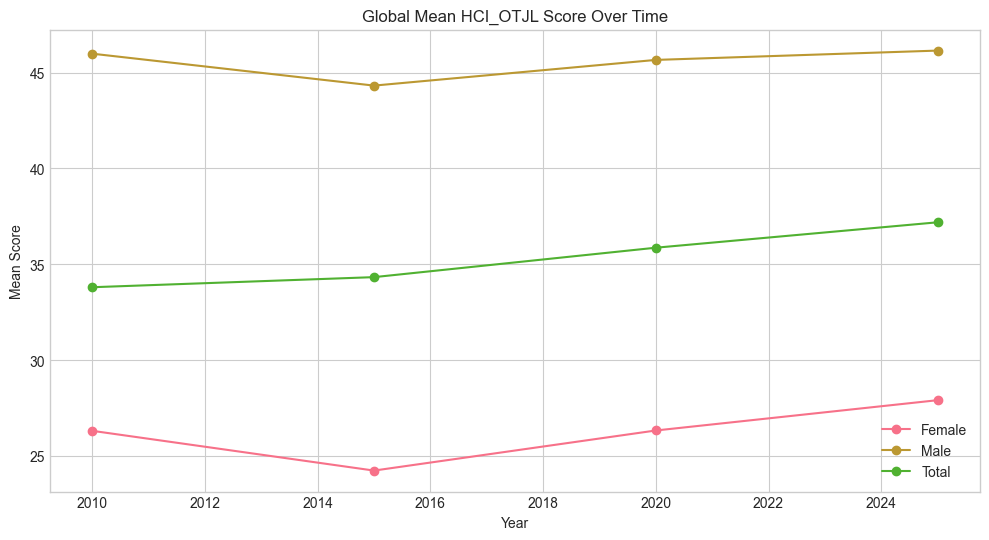

In [105]:
# ================================================
# TEMPORAL VISUALIZATION
# ================================================

def plot_temporal_trends(trends):
    plt.figure(figsize=(12,6))
    
    for sex in trends["Sex"].unique():
        data = trends[trends["Sex"] == sex]
        plt.plot(data["Year"], data["mean"], marker="o", label=sex)
    
    plt.title("Global Mean HCI_OTJL Score Over Time")
    plt.xlabel("Year")
    plt.ylabel("Mean Score")
    plt.legend()
    plt.show()

plot_temporal_trends(trends)


## GEOGRAPHIC RANKING

In [106]:
# ================================================
# GEOGRAPHIC ANALYSIS
# ================================================

def ranking_2025(df):
    data = df[(df["Year"] == 2025) & (df["Sex"] == "Total")]
    ranked = data.sort_values("HCI_OTJL", ascending=False)
    return ranked

ranked_2025 = ranking_2025(df_clean)

print("Top 10 Countries 2025")
display(ranked_2025.head(10)[["Country", "HCI_OTJL"]])

print("Bottom 10 Countries 2025")
display(ranked_2025.tail(10)[["Country", "HCI_OTJL"]])


Top 10 Countries 2025


,Country,HCI_OTJL
655,Qatar,72.684201
375,Iceland,67.954733
23,United Arab Emirates,67.381639
395,Japan,64.379205
135,Switzerland,62.628543
579,Netherlands,62.602727
595,New Zealand,61.498447
43,Australia,61.190980
519,Malta,60.760180
203,Germany,60.725741


Bottom 10 Countries 2025


,Country,HCI_OTJL
543,Mauritania,10.214762
371,Iraq,10.069636
587,Nepal,10.055881
647,West Bank and Gaza,8.878336
735,Eswatini,8.581845
767,Tajikistan,8.355901
775,Timor-Leste,7.634365
675,Sudan,7.421549
859,"Yemen, Rep.",5.949268
715,São Tomé and Príncipe,-3.261683


## GENDER GAP

In [107]:
# ================================================
# GENDER GAP ANALYSIS
# ================================================

def compute_gender_gap(df):
    gender = df[df["Sex"] != "Total"]
    
    pivot = gender.pivot_table(
        index=["Country", "Year"],
        columns="Sex",
        values="HCI_OTJL"
    ).reset_index()
    
    pivot["Gender_Gap"] = pivot["Male"] - pivot["Female"]
    return pivot

gender_gap = compute_gender_gap(df_clean)

gap_2025 = gender_gap[gender_gap["Year"] == 2025]

print("Mean Gender Gap 2025:", gap_2025["Gender_Gap"].mean())


Mean Gender Gap 2025: 18.5360311235977


## FORECASTING

In [108]:
# ================================================
# LINEAR FORECAST 2030
# ================================================

def forecast_country(data):
    X = data["Year"].values.reshape(-1,1)
    y = data["HCI_OTJL"].values
    
    if len(X) < 2:
        return None
    
    model = LinearRegression()
    model.fit(X,y)
    
    pred_2030 = model.predict([[2030]])[0]
    return pred_2030, model.coef_[0], model.score(X,y)

forecasts = []

for country in df_clean[df_clean["Sex"]=="Total"]["Country"].unique():
    country_data = df_clean[(df_clean["Country"]==country) & (df_clean["Sex"]=="Total")]
    result = forecast_country(country_data)
    
    if result:
        forecasts.append({
            "Country": country,
            "Forecast_2030": result[0],
            "Annual_Trend": result[1],
            "R2": result[2]
        })

df_forecast = pd.DataFrame(forecasts)

display(df_forecast.sort_values("Forecast_2030", ascending=False).head(10))


,Country,Forecast_2030,Annual_Trend,R2
134,Qatar,73.203965,-0.018037,0.015258
76,Iceland,71.480262,0.585303,0.915851
3,United Arab Emirates,70.416484,0.606969,1.000000
81,Japan,69.061438,0.787971,0.903738
106,Malta,68.993478,1.514218,0.993680
142,Solomon Islands,67.110811,1.825512,0.758715
40,Germany,64.724804,0.649049,0.965111
122,New Zealand,64.495051,0.518180,0.970544
17,Belarus,64.077064,0.712016,0.879750
48,Estonia,64.035795,0.948330,0.947235


## CLUSTERING

In [109]:
# ================================================
# COUNTRY CLUSTERING
# ================================================

cluster_data = df_clean[df_clean["Sex"]=="Total"].pivot(
    index="Country",
    columns="Year",
    values="HCI_OTJL"
).dropna()

scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_data)

kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE)
clusters = kmeans.fit_predict(scaled)

cluster_data["Cluster"] = clusters

print(cluster_data["Cluster"].value_counts())


Cluster
2    53
1    42
0    38
3    23
Name: count, dtype: int64


## 🚀  Feature Engineering (Clean + Correct)

In [110]:
def create_features(df, lags=(1,2,3)):
    
    df = df.copy()
    df = df.sort_values(["Country", "Year"])
    
    # Time trend per country
    df["year_trend"] = df["Year"] - df.groupby("Country")["Year"].transform("min")
    
    # Lag features
    for lag in lags:
        df[f"lag_{lag}"] = df.groupby("Country")["HCI_OTJL"].shift(lag)
    
    # Rolling mean (last 3 years)
    df["rolling_mean_3"] = (
        df.groupby("Country")["HCI_OTJL"]
          .shift(1)
          .rolling(3)
          .mean()
          .reset_index(level=0, drop=True)
    )
    
    return df


In [111]:
df_feat = create_features(df)
df_feat = df_feat.dropna().reset_index(drop=True)

In [112]:
X = df_feat.drop(columns=["HCI_OTJL"])
y = df_feat["HCI_OTJL"]

# Remove Country & Year from model input
X_model = X.drop(columns=["Country", "Year"])


In [113]:
# -------------------------------------------------
# 1️⃣ Separate target
# -------------------------------------------------
y = df_feat["HCI_OTJL"]

X = df_feat.drop(columns=["HCI_OTJL"])

# -------------------------------------------------
# 2️⃣ Drop identifiers if not predictive
# -------------------------------------------------
drop_cols = ["Country", "Year"]
X = X.drop(columns=[col for col in drop_cols if col in X.columns])

# -------------------------------------------------
# 3️⃣ Handle categorical columns properly
# -------------------------------------------------
categorical_cols = X.select_dtypes(include=["object"]).columns

if len(categorical_cols) > 0:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Ensure all remaining columns are numeric
X = X.astype(float)

# -------------------------------------------------
# 4️⃣ TimeSeries Split
# -------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

rmse_scores = []

# -------------------------------------------------
# 5️⃣ Cross Validation Loop
# -------------------------------------------------
for train_idx, test_idx in tscv.split(X):
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    rmse_scores.append(rmse)

print("Average RMSE:", np.mean(rmse_scores))


Average RMSE: 5.985195287534206


## 🚀  Forecast Until 2030 (Recursive)

In [114]:
def forecast_until_2030(df, model, target_year=2030):
    df_all = df.copy()
    last_year = df_all["Year"].max()
    print(f"Starting forecast from year {last_year}")

    for year in range(last_year + 1, target_year + 1):
        df_feat = create_features(df_all)

        # Keep only last year rows
        df_last = df_feat[df_feat["Year"] == df_feat["Year"].max()].copy()
        df_last["Year"] = year

        df_last = create_features(df_last)
        df_last = df_last.dropna()

        X_future = df_last.drop(columns=["HCI_OTJL", "Country", "Year"], errors="ignore")

        # Encode categorical if needed
        for col in X_future.columns:
            if X_future[col].dtype == "object":
                X_future[col] = X_future[col].astype("category").cat.codes

        preds = model.predict(X_future)
        df_last["HCI_OTJL"] = preds

        df_all = pd.concat([df_all, df_last[["Country", "Year", "HCI_OTJL"]]], ignore_index=True)

        print(f"Forecasted year: {year}")

    return df_all


## 🔥 6️⃣ SHAP Explainability

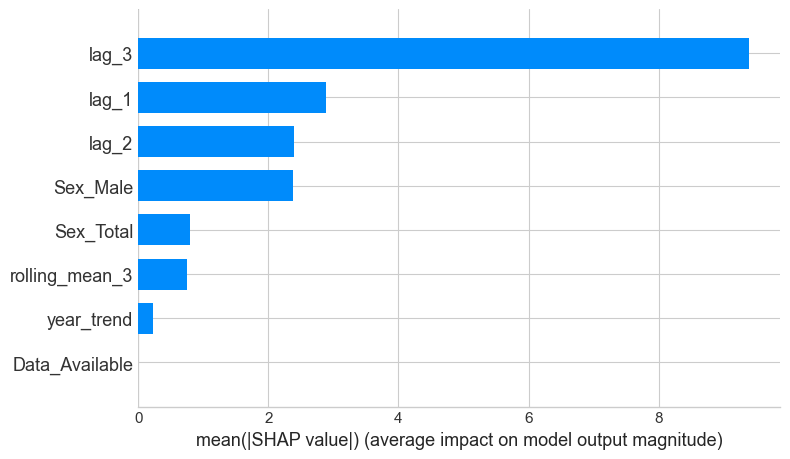

In [115]:
import shap

# -------------------------------------------------
# 1️⃣ Use the SAME encoded numeric training data used in model.fit
# -------------------------------------------------
# If you trained your model with:
# X = pd.get_dummies(df_feat.drop(columns=["HCI_OTJL"]), drop_first=True)
# model.fit(X, y)
# Then we MUST use X for SHAP

X_shap = X.copy()  # <-- fully numeric, one-hot encoded
X_shap = X_shap.astype(float)  # just to be safe

# -------------------------------------------------
# 2️⃣ Create TreeExplainer
# -------------------------------------------------
explainer = shap.TreeExplainer(model)

# -------------------------------------------------
# 3️⃣ Compute SHAP values
# -------------------------------------------------
shap_values = explainer.shap_values(X_shap)

# -------------------------------------------------
# 4️⃣ SHAP Summary Plot
# -------------------------------------------------
shap.summary_plot(shap_values, X_shap, plot_type="bar")


## 📊 SHAP Feature Importance Table

In [116]:
# Create SHAP importance DataFrame
shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,  # use the numeric/features dataframe
    "Mean_Absolute_SHAP": np.abs(shap_values).mean(axis=0)  # no .values
}).sort_values("Mean_Absolute_SHAP", ascending=False)

# Show importance
print(shap_importance)


          Feature  Mean_Absolute_SHAP
4           lag_3            9.396420
2           lag_1            2.886337
3           lag_2            2.398180
6        Sex_Male            2.376872
7       Sex_Total            0.790242
5  rolling_mean_3            0.749153
1      year_trend            0.225580
0  Data_Available            0.000000


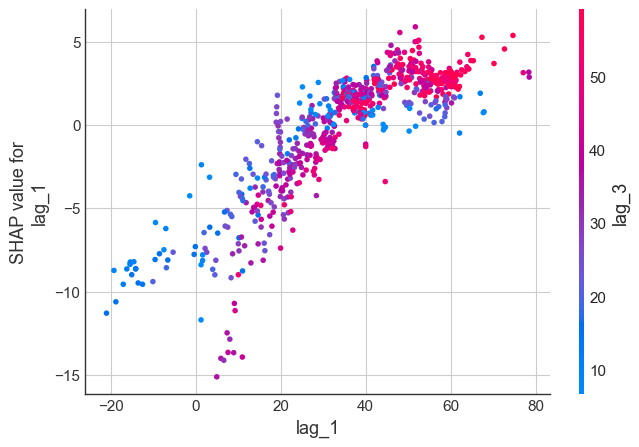

In [118]:
import shap

# SHAP dependence plot for feature "lag_1"
shap.dependence_plot(
    "lag_1",       # feature name
    shap_values,   # use the NumPy array returned by explainer
    X_shap         # must be the same numeric/encoded dataframe used for SHAP
)
